<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Part2_Vision_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Part II: Vision Task
## Scene Classification with CNN & Transfer Learning (MobileNetV2)

## Cell 1 — Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import SGD, Adam

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TF version:", tf.__version__)

TF version: 2.20.0


## Cell 2 — Upload & Extract Dataset

In [4]:
from google.colab import files

uploaded = files.upload()  # Upload Scene_Classification zip

for filename in uploaded.keys():
    with zipfile.ZipFile(filename, 'r') as z:
        z.extractall('/content/dataset')
    print(f"Extracted: {filename}")

# Verify structure
for root, dirs, files_list in os.walk('/content/dataset'):
    level  = root.replace('/content/dataset', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")

Saving Scene Classification-20260412T155152Z-3-001.zip to Scene Classification-20260412T155152Z-3-001.zip
Extracted: Scene Classification-20260412T155152Z-3-001.zip
dataset/
  Scene Classification/
    train/
    test/


## Cell 3 — Dataset Paths & Parameters

In [5]:
TRAIN_DIR   = '/content/dataset/Scene Classification/train/'
TEST_DIR    = '/content/dataset/Scene Classification/test/'
IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("Training images per class:")
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"  {cls}: {count}")

print("\nTesting images per class:")
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    print(f"  {cls}: {count}")

Training images per class:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382

Testing images per class:
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501


## Cell 4 — Task 2.5.1: Data Analysis & Visualisation

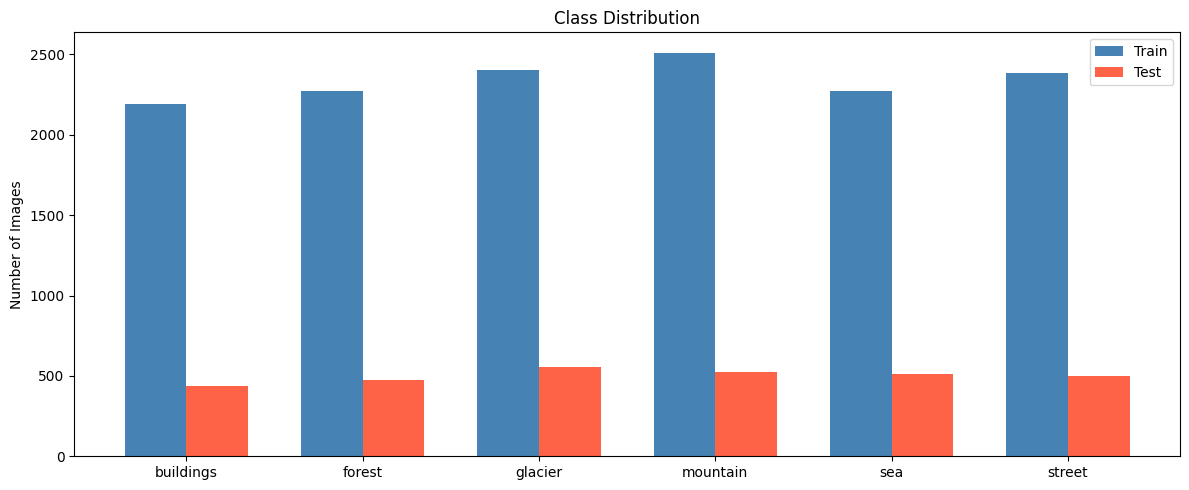

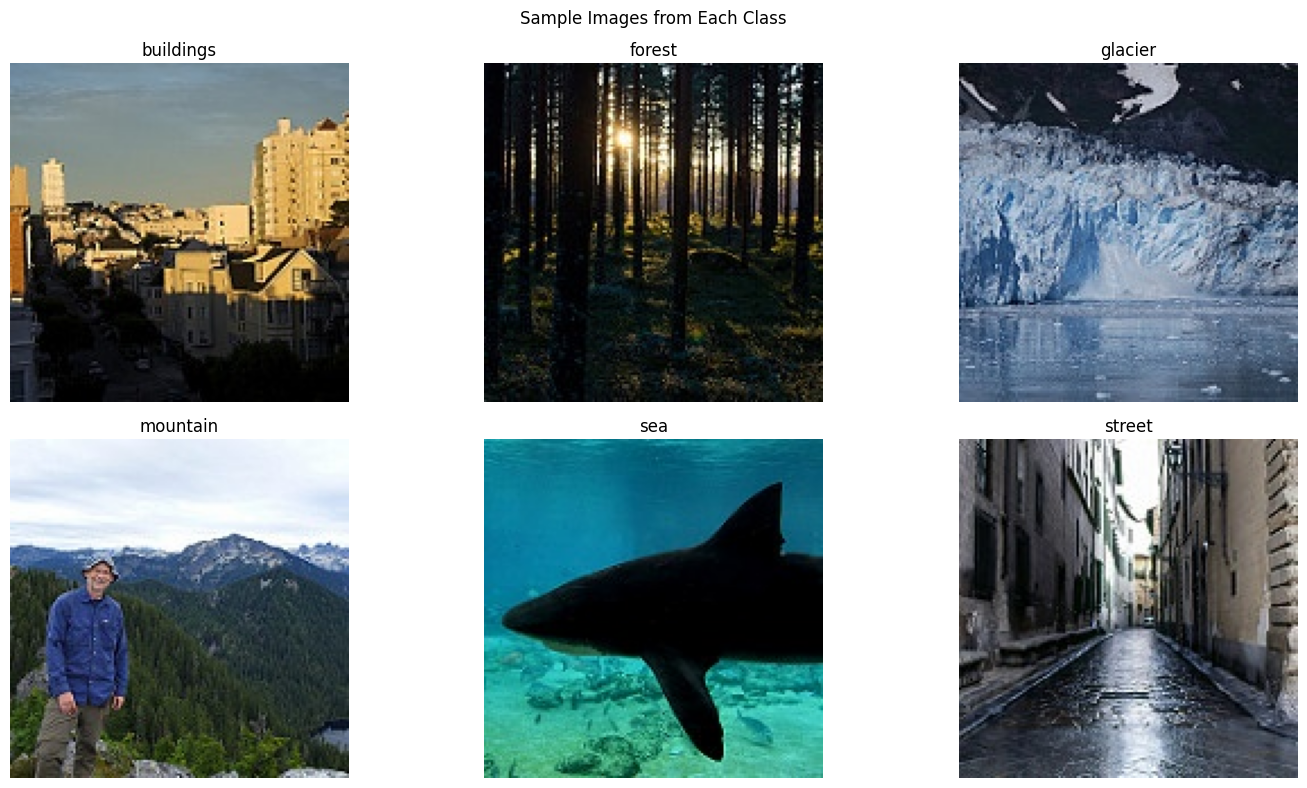

In [6]:
# Class distribution plot
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR,  c))) for c in CLASS_NAMES]

x     = np.arange(len(CLASS_NAMES))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, train_counts, width, label='Train', color='steelblue')
plt.bar(x + width/2, test_counts,  width, label='Test',  color='tomato')
plt.xticks(x, CLASS_NAMES)
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.legend()
plt.tight_layout()
plt.show()

# Sample images — safe version (skips corrupt files)
plt.figure(figsize=(15, 8))
for i, cls in enumerate(CLASS_NAMES):
    cls_path  = os.path.join(TRAIN_DIR, cls)
    valid_img = None
    for fname in os.listdir(cls_path):
        try:
            fpath     = os.path.join(cls_path, fname)
            valid_img = plt.imread(fpath)
            break
        except Exception:
            continue
    plt.subplot(2, 3, i + 1)
    if valid_img is not None:
        plt.imshow(valid_img)
        plt.title(cls)
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
import os

def remove_corrupt_images(folder):
    removed = 0
    for root, dirs, files in os.walk(folder):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                img = Image.open(fpath)
                img.verify()  # Check if valid
            except Exception:
                os.remove(fpath)
                print(f"Removed corrupt: {fpath}")
                removed += 1
    print(f"Total removed: {removed}")

print("Cleaning Train folder...")
remove_corrupt_images(TRAIN_DIR)
print("Cleaning Test folder...")
remove_corrupt_images(TEST_DIR)
print("Done! All corrupt images removed.")

Cleaning Train folder...
Removed corrupt: /content/dataset/Scene Classification/train/street/2666.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/18392.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/6833.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/15154.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/1139.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/3298.jpg
Removed corrupt: /content/dataset/Scene Classification/train/street/2939.jpg
Removed corrupt: /content/dataset/Scene Classification/train/sea/4578.jpg
Removed corrupt: /content/dataset/Scene Classification/train/sea/6369.jpg
Removed corrupt: /content/dataset/Scene Classification/train/sea/3041.jpg
Removed corrupt: /content/dataset/Scene Classification/train/sea/13762.jpg
Removed corrupt: /content/dataset/Scene Classification/train/sea/17040.jpg
Removed corrupt: /content/dataset/Scene Classification/train/s

## Cell 5 — Data Generators with Augmentation

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## Cell 6 — Visualise Augmented Images

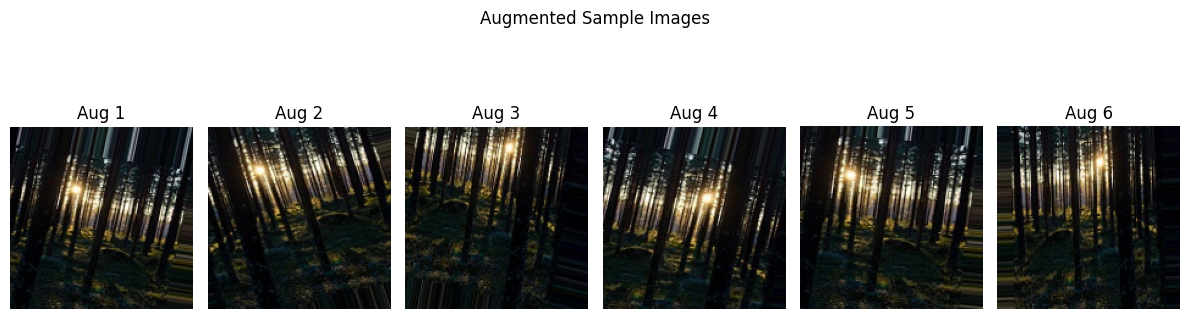

In [9]:
aug_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, horizontal_flip=True, zoom_range=0.2
)

sample_cls  = 'forest'
sample_path = os.path.join(TRAIN_DIR, sample_cls)
sample_img  = plt.imread(os.path.join(sample_path, os.listdir(sample_path)[0]))
sample_img  = np.expand_dims(sample_img, 0)
aug_gen     = aug_datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(12, 4))
for i in range(6):
    aug_img = next(aug_gen)[0]
    plt.subplot(1, 6, i + 1)
    plt.imshow(aug_img)
    plt.title(f'Aug {i+1}')
    plt.axis('off')
plt.suptitle('Augmented Sample Images')
plt.tight_layout()
plt.show()

## Cell 7 — Task 2.5.2: Baseline CNN Model

In [10]:
baseline_model = Sequential([
    Conv2D(32,  (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64,  (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="Baseline_CNN")

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,604,998 (36.64 MB)

 Trainable params: 9,604,998 (36.64 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 8 — Train Baseline Model

In [11]:
start = time.time()

history_base = baseline_model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1),
        keras.callbacks.ModelCheckpoint('baseline_best.keras', save_best_only=True, verbose=1)
    ]
)

baseline_time = time.time() - start
print(f"\nBaseline training time: {baseline_time:.2f} seconds")

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4215 - loss: 1.4022
Epoch 1: val_loss improved from None to 1.03282, saving model to baseline_best.keras

Epoch 1: finished saving model to baseline_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 105s 278ms/step - accuracy: 0.4905 - loss: 1.2552 - val_accuracy: 0.5794 - val_loss: 1.0328
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5888 - loss: 1.0355
Epoch 2: val_loss improved from 1.03282 to 0.90668, saving model to baseline_best.keras

Epoch 2: finished saving model to baseline_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 88s 252ms/step - accuracy: 0.5936 - loss: 1.0311 - val_accuracy: 0.6484 - val_loss: 0.9067
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6302 - loss: 0.9690
Epoch 3: val_loss did not improve from 0.90668
350/350 ━━━━━━━━━━━━━━━━━━━━ 87s 248ms/step - accuracy: 0.6453 - loss: 0.9398 - val_accuracy: 0.6470 - val_loss: 0.9127
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 19

## Cell 9 — Plot & Evaluate Helper Functions

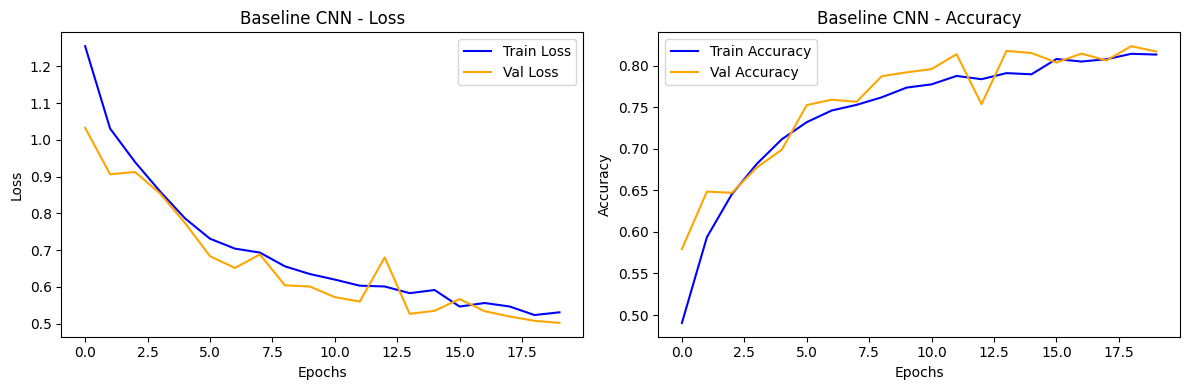


  Baseline CNN
Test Loss: 0.4868 | Test Accuracy: 0.8283
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.68      0.93      0.78       437
      forest       0.95      0.98      0.96       474
     glacier       0.81      0.79      0.80       553
    mountain       0.79      0.75      0.77       525
         sea       0.89      0.77      0.83       510
      street       0.90      0.77      0.83       501

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.83      0.83      3000



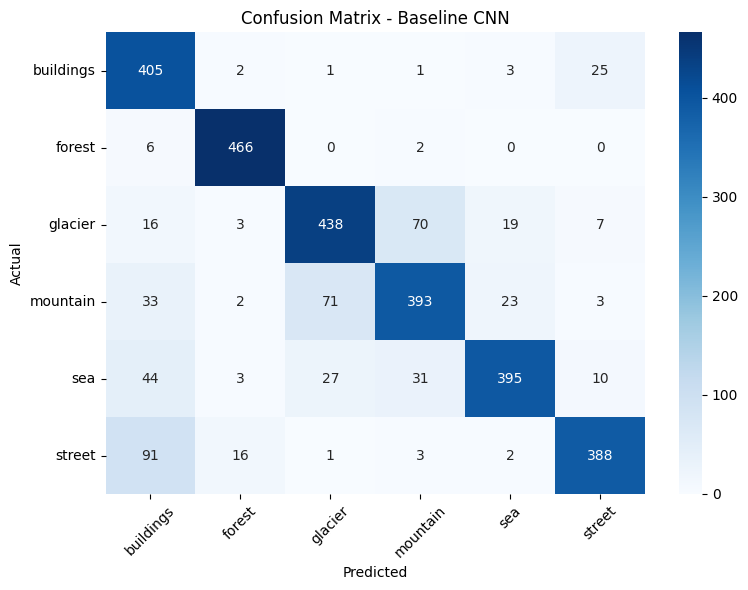

In [12]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'],     label='Train Loss',     color='blue')
    plt.plot(history.history['val_loss'], label='Val Loss',       color='orange')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_gen, name):
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=45); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()
    return acc

plot_history(history_base, 'Baseline CNN')
base_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

## Cell 10 — Task 2.5.3: Deeper CNN with Regularization

In [13]:
deeper_model = Sequential([
    Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(),
    Conv2D(32,  (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2), Dropout(0.25),

    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64,  (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2), Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2), Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2), Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.5),
    Dense(256, activation='relu'), Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="Deeper_CNN")

deeper_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,04

 Total params: 11,958,566 (45.62 MB)

 Trainable params: 11,956,582 (45.61 MB)

 Non-trainable params: 1,984 (7.75 KB)

## Cell 11 — Train Deeper Model

Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.4515 - loss: 1.4351
Epoch 1: val_loss improved from None to 2.68286, saving model to deeper_best.keras

Epoch 1: finished saving model to deeper_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 136s 328ms/step - accuracy: 0.5336 - loss: 1.1951 - val_accuracy: 0.1992 - val_loss: 2.6829
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6232 - loss: 0.9895
Epoch 2: val_loss improved from 2.68286 to 0.95274, saving model to deeper_best.keras

Epoch 2: finished saving model to deeper_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 107s 277ms/step - accuracy: 0.6363 - loss: 0.9537 - val_accuracy: 0.6398 - val_loss: 0.9527
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6928 - loss: 0.8241
Epoch 3: val_loss improved from 0.95274 to 0.81037, saving model to deeper_best.keras

Epoch 3: finished saving model to deeper_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.6964 - loss: 0.8191 - 

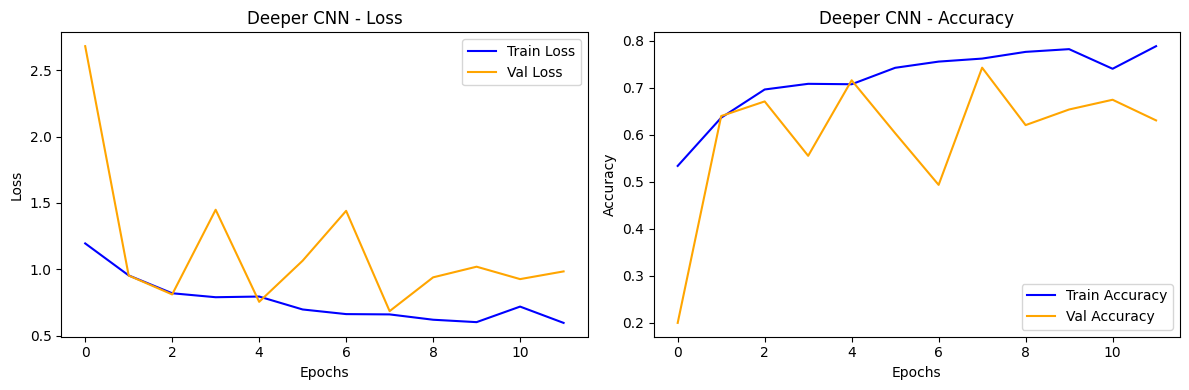


  Deeper CNN
Test Loss: 1.0151 | Test Accuracy: 0.6360
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.55      0.95      0.69       437
      forest       0.90      0.96      0.93       474
     glacier       0.82      0.02      0.03       553
    mountain       0.56      0.76      0.64       525
         sea       0.54      0.87      0.67       510
      street       0.95      0.38      0.54       501

    accuracy                           0.64      3000
   macro avg       0.72      0.65      0.58      3000
weighted avg       0.72      0.64      0.57      3000



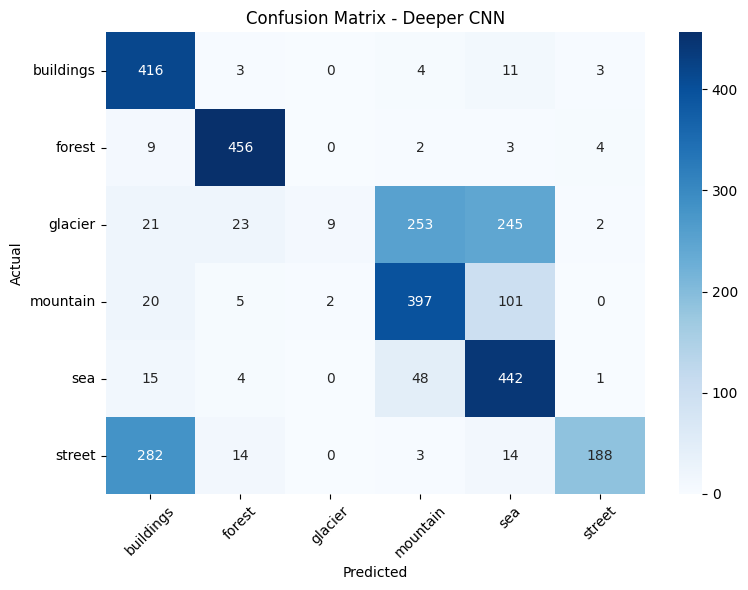

In [14]:
start = time.time()

history_deep = deeper_model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1),
        keras.callbacks.ModelCheckpoint('deeper_best.keras', save_best_only=True, verbose=1)
    ]
)

deeper_time = time.time() - start
print(f"\nDeeper model training time: {deeper_time:.2f} seconds")
plot_history(history_deep, 'Deeper CNN')
deep_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN')

## Cell 12 — Task 2.5.4: SGD vs Adam Comparison

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 107s 284ms/step - accuracy: 0.1748 - loss: 2.3193 - val_accuracy: 0.1792 - val_loss: 1.7913
Epoch 2/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.1777 - loss: 1.7923 - val_accuracy: 0.1792 - val_loss: 1.7910
Epoch 3/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.1801 - loss: 1.7915 - val_accuracy: 0.1713 - val_loss: 1.7917
Epoch 4/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 268ms/step - accuracy: 0.1755 - loss: 1.7917 - val_accuracy: 0.1792 - val_loss: 1.7912
Epoch 5/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.1746 - loss: 1.7914 - val_accuracy: 0.1792 - val_loss: 1.7915
Epoch 6/20
350/350 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.1743 - loss: 1.7915 - val_accuracy: 0.1713 - val_loss: 1.7912
Epoch 6: early stopping


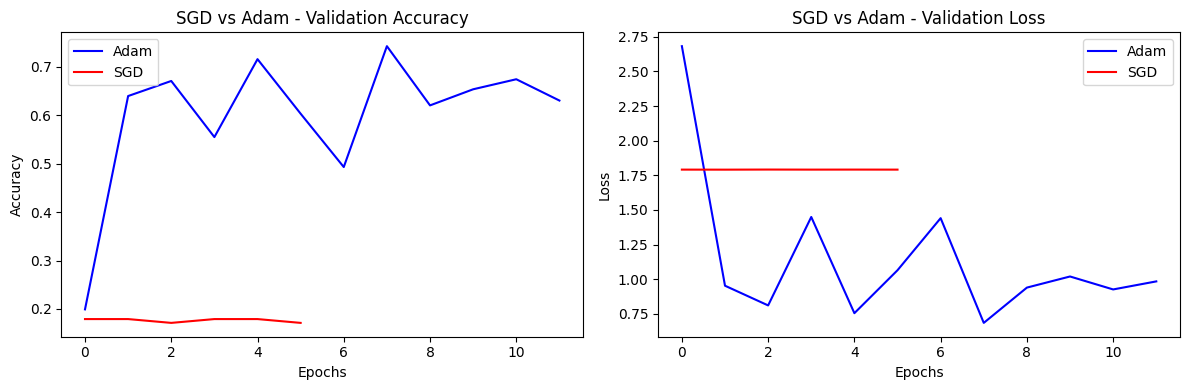

In [15]:
deeper_sgd = Sequential([
    Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(), Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),
    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),
    Flatten(),
    Dense(256, activation='relu'), Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="Deeper_SGD")

deeper_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy', metrics=['accuracy']
)

history_sgd = deeper_sgd.fit(
    train_gen, epochs=20, validation_data=val_gen,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, verbose=1)]
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_deep.history['val_accuracy'], label='Adam', color='blue')
plt.plot(history_sgd.history['val_accuracy'],  label='SGD',  color='red')
plt.title('SGD vs Adam - Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_deep.history['val_loss'], label='Adam', color='blue')
plt.plot(history_sgd.history['val_loss'],  label='SGD',  color='red')
plt.title('SGD vs Adam - Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

## Cell 13 — Task 2.5.4: Ablation Study (Remove Dropout)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 102s 276ms/step - accuracy: 0.5107 - loss: 2.3812 - val_accuracy: 0.2486 - val_loss: 2.7395
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 91s 261ms/step - accuracy: 0.6307 - loss: 0.9615 - val_accuracy: 0.6642 - val_loss: 0.8761
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.6791 - loss: 0.8427 - val_accuracy: 0.6563 - val_loss: 0.8984
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.7216 - loss: 0.7579 - val_accuracy: 0.6402 - val_loss: 0.9786
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 93s 264ms/step - accuracy: 0.7489 - loss: 0.6896 - val_accuracy: 0.7271 - val_loss: 0.7357
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 92s 262ms/step - accuracy: 0.7689 - loss: 0.6369 - val_accuracy: 0.7121 - val_loss: 0.7702
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 92s 263ms/step - accuracy: 0.7758 - loss: 0.6140 - val_accuracy: 0.6770 - val_loss: 1.0284
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 142s 264ms/step - accuracy: 0.7929 - loss:

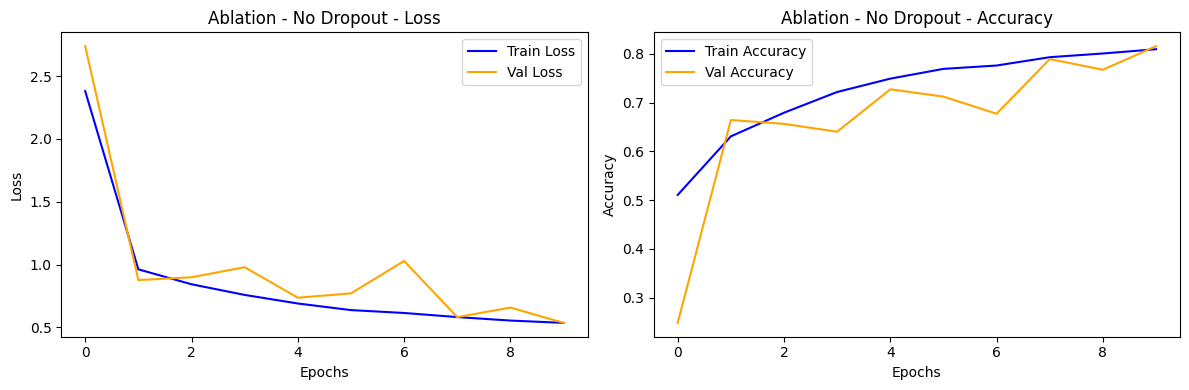


  Ablation - No Dropout
Test Loss: 0.5166 | Test Accuracy: 0.8170
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.70      0.90      0.79       437
      forest       0.91      0.98      0.95       474
     glacier       0.79      0.78      0.78       553
    mountain       0.78      0.78      0.78       525
         sea       0.90      0.72      0.80       510
      street       0.85      0.77      0.81       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



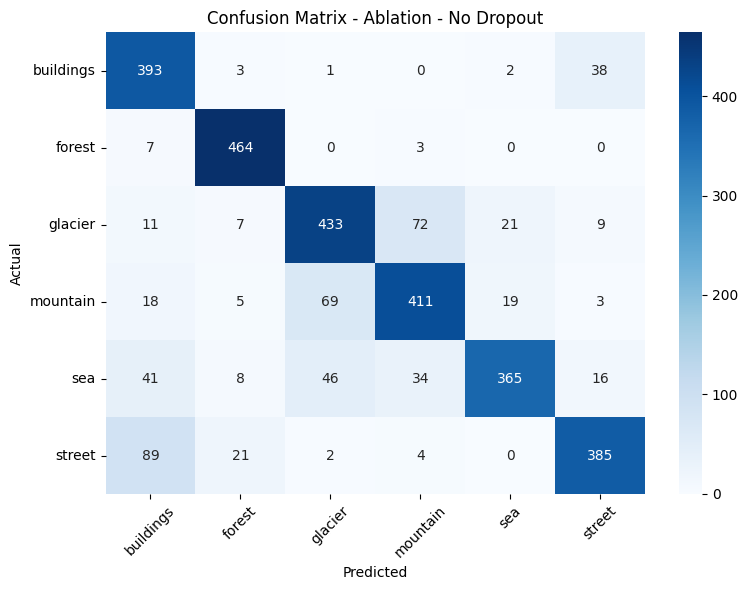

In [16]:
ablation_model = Sequential([
    Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(150, 150, 3)),
    BatchNormalization(), Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(64,  (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(), Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')  # No Dropout
], name="Ablation_No_Dropout")

ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_ablation = ablation_model.fit(
    train_gen, epochs=10, validation_data=val_gen,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1)]
)

plot_history(history_ablation, 'Ablation - No Dropout')
ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation - No Dropout')

## Cell 14 — Task 2.6 Part B: MobileNetV2 Data Generators

In [17]:
IMG_SIZE_TL = (224, 224)

tl_train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.2,
    height_shift_range=0.2, horizontal_flip=True, zoom_range=0.2,
    validation_split=0.2
)
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## Cell 15 — Load MobileNetV2 & Build Model

In [18]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation='relu')(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name="MobileNetV2_Transfer")

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 361,606 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Cell 16 — Feature Extraction Training

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.7427 - loss: 0.6658
Epoch 1: val_loss improved from None to 0.34458, saving model to mobilenet_best.keras

Epoch 1: finished saving model to mobilenet_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 217s 567ms/step - accuracy: 0.8018 - loss: 0.5153 - val_accuracy: 0.8745 - val_loss: 0.3446
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8501 - loss: 0.4152
Epoch 2: val_loss improved from 0.34458 to 0.33685, saving model to mobilenet_best.keras

Epoch 2: finished saving model to mobilenet_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 169s 483ms/step - accuracy: 0.8534 - loss: 0.4011 - val_accuracy: 0.8759 - val_loss: 0.3368
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8580 - loss: 0.3715
Epoch 3: val_loss did not improve from 0.33685
350/350 ━━━━━━━━━━━━━━━━━━━━ 167s 477ms/step - accuracy: 0.8596 - loss: 0.3707 - val_accuracy: 0.8677 - val_loss: 0.3525
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━

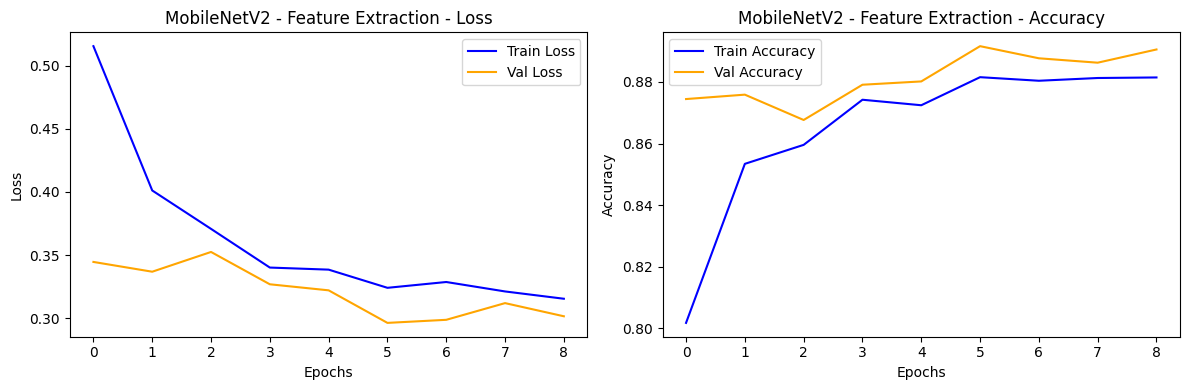

In [19]:
start = time.time()

history_tl = tl_model.fit(
    tl_train_gen, epochs=10, validation_data=tl_val_gen,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1),
        keras.callbacks.ModelCheckpoint('mobilenet_best.keras', save_best_only=True, verbose=1)
    ]
)

tl_time = time.time() - start
print(f"\nFeature extraction time: {tl_time:.2f} seconds")
plot_history(history_tl, 'MobileNetV2 - Feature Extraction')

## Cell 17 — Fine Tuning Phase

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7628 - loss: 0.7409
Epoch 1: val_loss improved from None to 0.30131, saving model to mobilenet_finetuned.keras

Epoch 1: finished saving model to mobilenet_finetuned.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 202s 531ms/step - accuracy: 0.8073 - loss: 0.5681 - val_accuracy: 0.8909 - val_loss: 0.3013
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.8575 - loss: 0.3814
Epoch 2: val_loss improved from 0.30131 to 0.29560, saving model to mobilenet_finetuned.keras

Epoch 2: finished saving model to mobilenet_finetuned.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 493ms/step - accuracy: 0.8624 - loss: 0.3724 - val_accuracy: 0.8984 - val_loss: 0.2956
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8659 - loss: 0.3647
Epoch 3: val_loss improved from 0.29560 to 0.28811, saving model to mobilenet_finetuned.keras

Epoch 3: finished saving model to mobilenet_finetuned.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 168

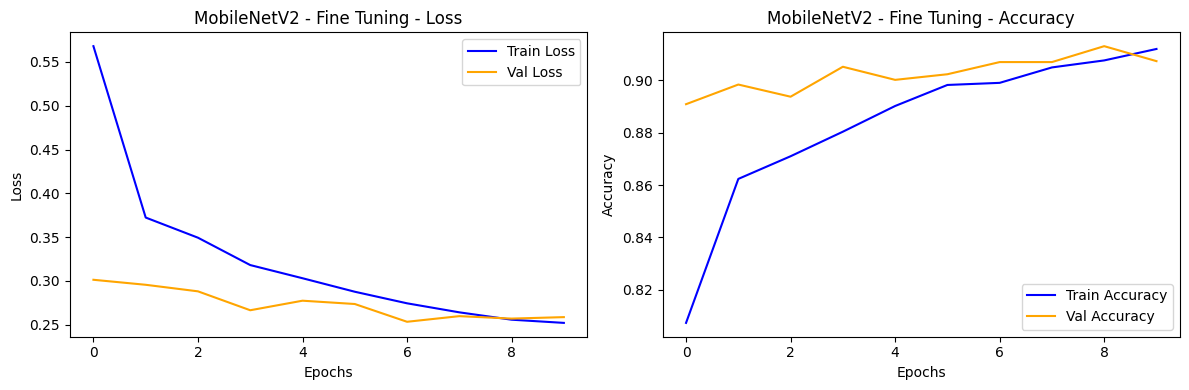


  MobileNetV2 Transfer Learning
Test Loss: 0.2126 | Test Accuracy: 0.9193
94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.94      0.91      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.87      0.85      0.86       553
    mountain       0.88      0.84      0.86       525
         sea       0.94      0.97      0.95       510
      street       0.92      0.95      0.94       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



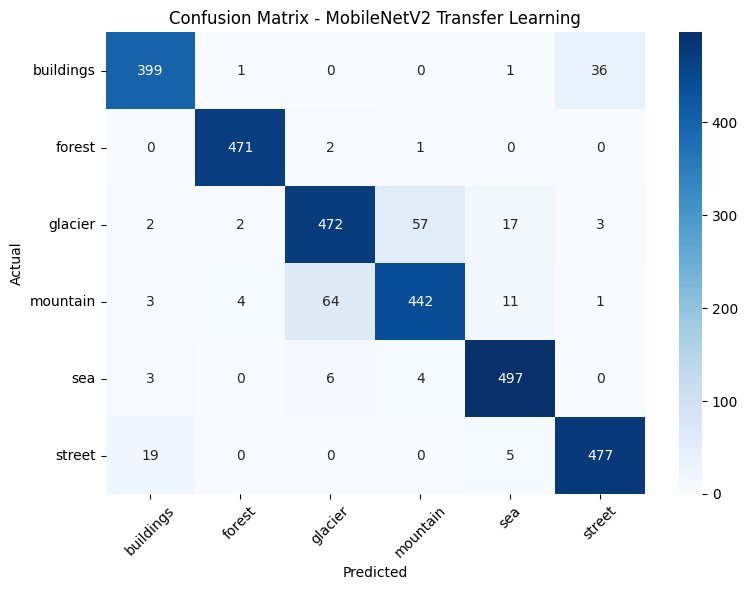

In [20]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = tl_model.fit(
    tl_train_gen, epochs=10, validation_data=tl_val_gen,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1),
        keras.callbacks.ModelCheckpoint('mobilenet_finetuned.keras', save_best_only=True, verbose=1)
    ]
)

plot_history(history_ft, 'MobileNetV2 - Fine Tuning')
tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Transfer Learning')

## Cell 18 — Final Model Comparison

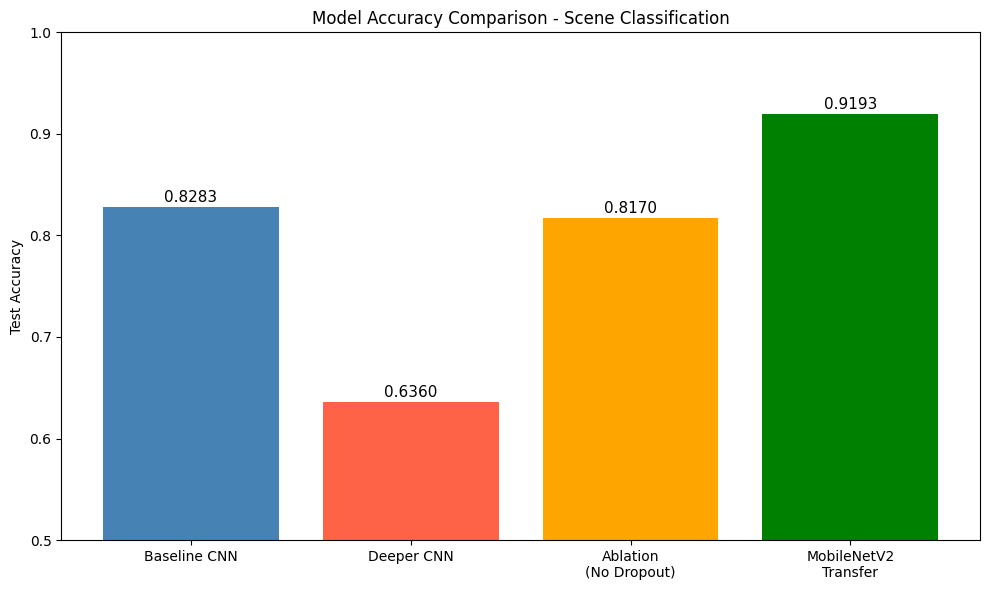

Baseline CNN:              0.8283
Deeper CNN:                0.6360
Ablation (No Dropout):     0.8170
MobileNetV2 Transfer:      0.9193

Baseline Training Time:    1761.80s
Deeper Training Time:      1253.95s
MobileNetV2 Training Time: 1549.47s


In [21]:
models     = ['Baseline CNN', 'Deeper CNN', 'Ablation\n(No Dropout)', 'MobileNetV2\nTransfer']
accuracies = [base_acc, deep_acc, ablation_acc, tl_acc]
colors     = ['steelblue', 'tomato', 'orange', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors)
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison - Scene Classification')
plt.ylabel('Test Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout(); plt.show()

print(f"Baseline CNN:              {base_acc:.4f}")
print(f"Deeper CNN:                {deep_acc:.4f}")
print(f"Ablation (No Dropout):     {ablation_acc:.4f}")
print(f"MobileNetV2 Transfer:      {tl_acc:.4f}")
print(f"\nBaseline Training Time:    {baseline_time:.2f}s")
print(f"Deeper Training Time:      {deeper_time:.2f}s")
print(f"MobileNetV2 Training Time: {tl_time:.2f}s")

## Cell 19 — Sample Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step


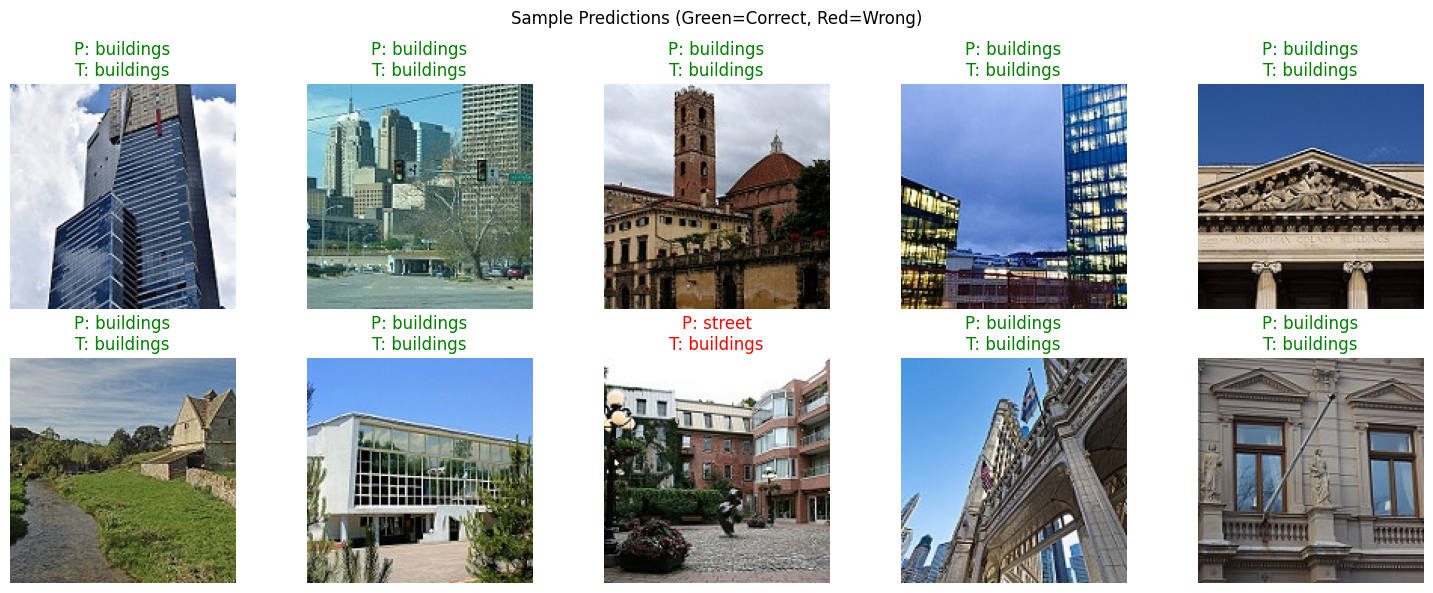

In [22]:
tl_test_gen.reset()
preds       = tl_model.predict(tl_test_gen)
pred_labels = np.argmax(preds, axis=1)
true_labels = tl_test_gen.classes
filenames   = tl_test_gen.filenames

plt.figure(figsize=(15, 6))
for i in range(10):
    img_path = os.path.join(TEST_DIR, filenames[i])
    img      = plt.imread(img_path)
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    color = 'green' if pred_labels[i] == true_labels[i] else 'red'
    plt.title(f"P: {CLASS_NAMES[pred_labels[i]]}\nT: {CLASS_NAMES[true_labels[i]]}", color=color)
    plt.axis('off')
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout(); plt.show()